In [47]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

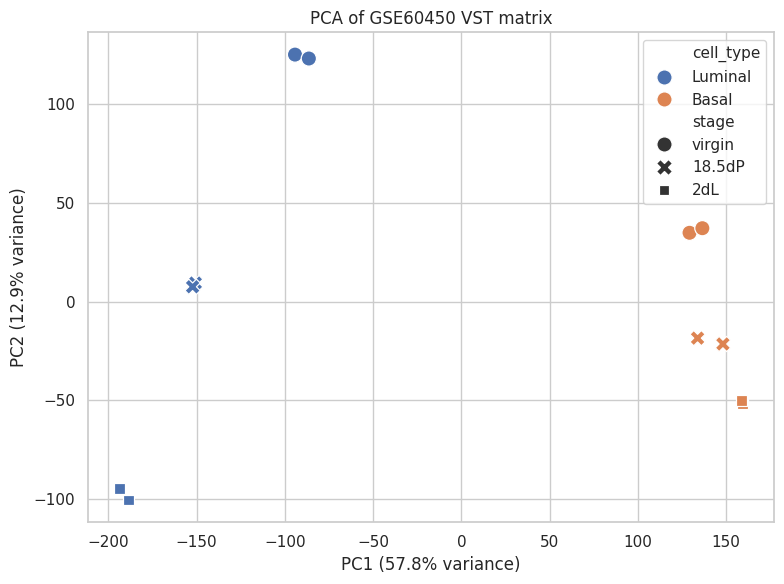

In [48]:
# load transformed data (VST or rlog)
project_root = Path.cwd().parent
vst_matrix = pd.read_csv(project_root / "quants" / "GSE60450_vst_matrix.csv", index_col=0) 
metadata = pd.read_csv(project_root / "quants" / "GSE60450_metadata.csv", index_col=0)

# perform PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(vst_matrix)

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=vst_matrix.index).join(metadata)

# plot PCA
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cell_type", style="stage", s=120)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of GSE60450 VST matrix")
plt.tight_layout()
plt.show()


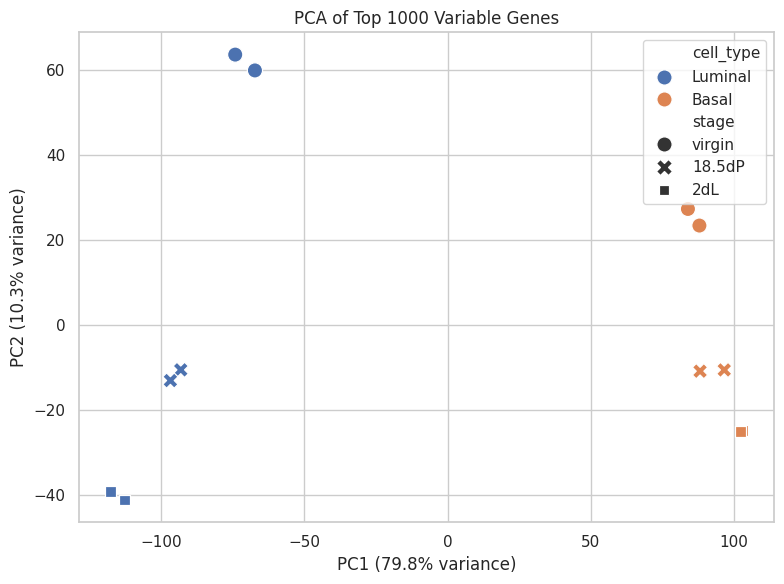

In [49]:
# select top 1000 most variable genes 
top_n = 1000
gene_var = vst_matrix.var(axis=0) 
top_genes = gene_var.nlargest(top_n).index
vst_matrix_top = vst_matrix[top_genes]

# perform PCA on top variable genes
pca_top = PCA(n_components=2)
pcs_top = pca_top.fit_transform(vst_matrix_top)
pca_top_df = pd.DataFrame(pcs_top, columns=["PC1", "PC2"], index=vst_matrix_top.index).join(metadata)

#plot PCA of top variable genes
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_top_df, x="PC1", y="PC2", hue="cell_type", style="stage", s=120)
plt.xlabel(f"PC1 ({pca_top.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_top.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of Top 1000 Variable Genes")
plt.tight_layout()
plt.show()

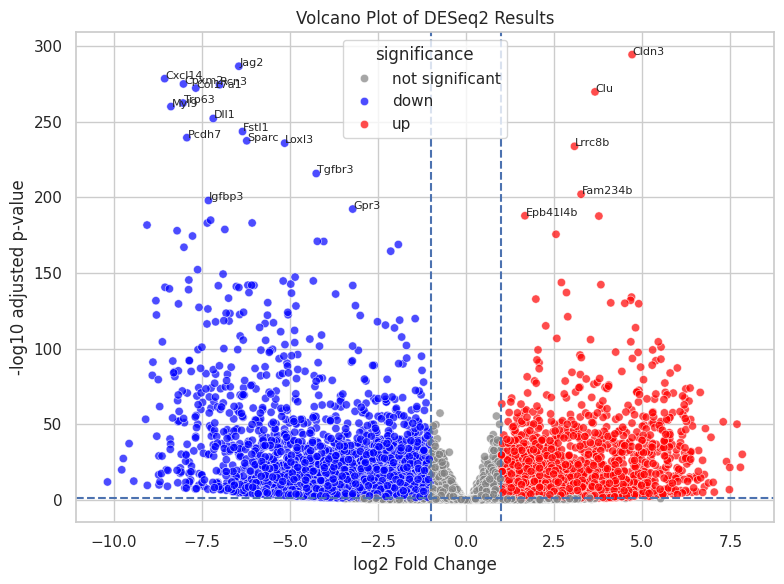

In [50]:
# DEG visualization (Volcano plot)
# load GSE60450_deseq2_results.csv and create volcano plot dataframe
deg_matrix = pd.read_csv(project_root / "quants" / "GSE60450_deseq2_results.csv", index_col=0)

volcano_df = deg_matrix[["gene_name", "log2FoldChange", "padj"]].copy()
volcano_df = volcano_df.dropna(subset=["log2FoldChange", "padj"])
volcano_df = volcano_df[volcano_df["padj"] > 0]
volcano_df["minus_log10_padj"] = -np.log10(volcano_df["padj"])
volcano_df["significance"] = "not significant"
volcano_df.loc[
    (volcano_df["padj"] < 0.05) & (volcano_df["log2FoldChange"] > 1),
    "significance"
] = "up"
volcano_df.loc[
    (volcano_df["padj"] < 0.05) & (volcano_df["log2FoldChange"] < -1),
    "significance"
] = "down"

# plot volcano
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=volcano_df,
    x="log2FoldChange",
    y="minus_log10_padj",
    hue="significance",
    palette={"up": "red", "down": "blue", "not significant": "gray"},
    alpha=0.7
)
plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(y=-np.log10(0.05), linestyle="--")
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano Plot of DESeq2 Results")

# label top 20 significant genes
label_df = volcano_df[volcano_df["significance"] != "not significant"].sort_values("padj").head(20)
label_df = label_df.dropna(subset=['gene_name'])
for _, row in label_df.iterrows():
    plt.text(
        row["log2FoldChange"] + 0.02,
        row["minus_log10_padj"] + 0.02,
        row["gene_name"],
        fontsize=8
    )
plt.tight_layout()
plt.show()